苹果类别数量: 4

--- 训练 ResNet18 ---
ResNet Epoch 1 Acc: 0.00%
ResNet Epoch 2 Acc: 0.00%
ResNet Epoch 3 Acc: 100.00%
ResNet Epoch 4 Acc: 100.00%
ResNet Epoch 5 Acc: 100.00%

--- 训练 MobileNetV2 ---
MobileNet Epoch 1 Acc: 100.00%
MobileNet Epoch 2 Acc: 100.00%
MobileNet Epoch 3 Acc: 100.00%
MobileNet Epoch 4 Acc: 100.00%
MobileNet Epoch 5 Acc: 100.00%


/opt/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33529 (\N{CJK UNIFIED IDEOGRAPH-82F9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23475 (\N{CJK UNIFIED IDEOGRAPH-5BB3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/venv/

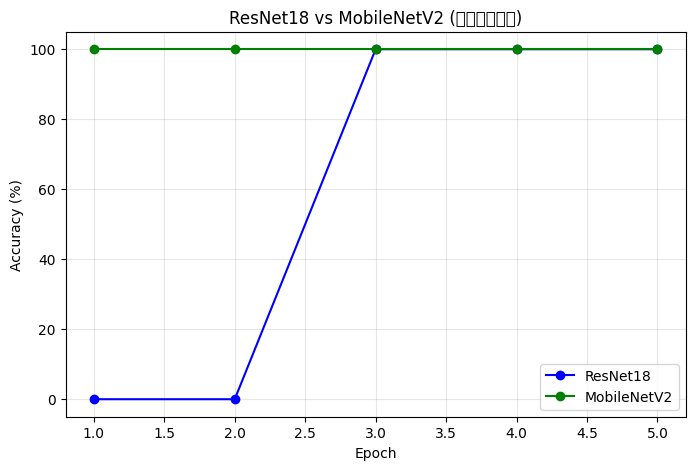

ResNet18 最佳准确率: 100.0
MobileNetV2 最佳准确率: 100.0


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt

# ----------------------
# 1. 数据准备（和你A/B一致）
# ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "./data/PlantVillage"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 只取苹果数据
full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
apple_indices = [i for i, c in enumerate(full_dataset.classes) if c.startswith("Apple")]
apple_dataset = Subset(full_dataset, apple_indices)

train_size = int(0.8 * len(apple_dataset))
val_size = len(apple_dataset) - train_size
train_dataset, val_dataset = random_split(apple_dataset, [train_size, val_size])
val_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
num_classes = 4
print("苹果类别数量:", num_classes)

# ----------------------
# 2. 定义模型（简化版，避免参数判断错误）
# ----------------------
# ResNet18
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model_resnet.parameters():
    p.requires_grad = False
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, num_classes)
model_resnet.fc.requires_grad = True
model_resnet = model_resnet.to(device)

# MobileNetV2
model_mobile = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
for p in model_mobile.parameters():
    p.requires_grad = False
model_mobile.classifier[1] = nn.Linear(model_mobile.classifier[1].in_features, num_classes)
model_mobile.classifier[1].requires_grad = True
model_mobile = model_mobile.to(device)

# ----------------------
# 3. 训练函数（每个模型单独调用，不共用函数，彻底避免参数错误）
# ----------------------
def train_resnet():
    opt = optim.Adam(model_resnet.fc.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    accs = []
    for e in range(5):
        model_resnet.train()
        for imgs, labs in train_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            loss = criterion(model_resnet(imgs), labs)
            opt.zero_grad()
            loss.backward()
            opt.step()
        # 验证
        model_resnet.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labs in val_loader:
                imgs, labs = imgs.to(device), labs.to(device)
                _, pred = model_resnet(imgs).max(1)
                correct += pred.eq(labs).sum().item()
                total += labs.size(0)
        acc = 100.0 * correct / total
        accs.append(acc)
        print(f"ResNet Epoch {e+1} Acc: {acc:.2f}%")
    return accs

def train_mobile():
    opt = optim.Adam(model_mobile.classifier[1].parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    accs = []
    for e in range(5):
        model_mobile.train()
        for imgs, labs in train_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            loss = criterion(model_mobile(imgs), labs)
            opt.zero_grad()
            loss.backward()
            opt.step()
        # 验证
        model_mobile.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labs in val_loader:
                imgs, labs = imgs.to(device), labs.to(device)
                _, pred = model_mobile(imgs).max(1)
                correct += pred.eq(labs).sum().item()
                total += labs.size(0)
        acc = 100.0 * correct / total
        accs.append(acc)
        print(f"MobileNet Epoch {e+1} Acc: {acc:.2f}%")
    return accs

# ----------------------
# 4. 开始训练 + 对比图
# ----------------------
print("\n--- 训练 ResNet18 ---")
res_acc = train_resnet()

print("\n--- 训练 MobileNetV2 ---")
mob_acc = train_mobile()

plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), res_acc, "bo-", label="ResNet18")
plt.plot(range(1, 6), mob_acc, "go-", label="MobileNetV2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 vs MobileNetV2 (苹果病害分类)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("ResNet18 最佳准确率:", max(res_acc))
print("MobileNetV2 最佳准确率:", max(mob_acc))